# Лабораторная работа №3 — Детекция объектов на видео: классические и нейросетевые методы

**Цель:** реализовать и сравнить несколько подходов к детекции объектов (`car`, `multivan`) на видео городского трафика:
1. Извлечь bounding box'ы из аннотированного видео с помощью HSV-цветовых масок (OpenCV)
2. Применить метод вычитания фона (MOG2) как альтернативный способ выделения объектов
3. Оценить качество обоих методов через IoU и сравнить с эталонной разметкой (CVAT XML)
4. Сформировать датасет в формате COCO JSON
5. Обучить детектор Faster R-CNN на полученных аннотациях и оценить его качество по mAP

**Поддерживаемые типы объектов:** `car` (легковой автомобиль), `multivan` (микроавтобус/минивэн).

## 1. Исходные данные

### 1.1 Описание видеоматериалов


В качестве исходных данных используются два видео городского трафика:

| Файл | Описание |
|---|---|
| `DATA/input.mp4` | Чистое видео без разметки — целевые кадры для итогового результата |
| `DATA/output.mp4` | Видео с нарисованными цветными bounding box'ами — источник для извлечения координат |
| `DATA/annotations.xml` | Ручная разметка CVAT с типами объектов (`car`, `multivan`) — эталон для оценки |

**Идея:** цветные рамки в `output.mp4` нанесены с уникальными цветами — по HSV-маскам можно локализовать каждый бокс и восстановить его координаты.


## 2. Разбиение видео на кадры

Функция `extract_frames` покадрово читает видеофайл и сохраняет каждый кадр как JPEG.  
Возвращает метаданные видео (FPS, разрешение) и список путей к сохранённым кадрам.


In [3]:
import cv2
import os

def extract_frames(video_path, output_dir):
    """
    Разбивает видеофайл на отдельные кадры и сохраняет их в директорию.

    Параметры:
        video_path  : путь к видеофайлу
        output_dir  : директория для сохранения кадров (создаётся при отсутствии)

    Возвращает словарь:
        fps          – частота кадров исходного видео
        total_frames – общее число кадров
        width, height – разрешение
        frame_paths  – список путей ко всем сохранённым кадрам
    """
    os.makedirs(output_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    frame_idx = 0
    saved_paths = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_path = os.path.join(output_dir, f"frame_{frame_idx:05d}.jpg")
        cv2.imwrite(frame_path, frame)
        saved_paths.append(frame_path)
        frame_idx += 1
    
    cap.release()
    
    return {
        "fps": fps,
        "total_frames": frame_idx,
        "width": width,
        "height": height,
        "frame_paths": saved_paths
    }

# output.mp4 — аннотированное видео (для извлечения боксов)
info = extract_frames("DATA/output.mp4", "DATA/frames_output/")
print(f"output.mp4 -> кадров: {info['total_frames']}  |  FPS: {info['fps']}  |  {info['width']}×{info['height']}")

# input.mp4 — чистое видео (для наложения результатов и обучения модели)
info_input = extract_frames("DATA/input.mp4", "DATA/frames_input/")
print(f"input.mp4  -> кадров: {info_input['total_frames']}  |  FPS: {info_input['fps']}  |  {info_input['width']}×{info_input['height']}")


output.mp4 -> кадров: 301  |  FPS: 30.0  |  1920×1080
input.mp4  -> кадров: 301  |  FPS: 30.0  |  1920×1080


## 3. Извлечение bounding box'ов из output-видео

Подход: каждый бокс нарисован уникальным цветом → строим HSV-маску по всем известным цветам, находим контуры и вычисляем описывающие прямоугольники.


### 3.1 Зондирование пикселей для подбора HSV-диапазонов

Считываем HSV-значение конкретного пикселя — используется для ручного подбора диапазонов в `colors.py`.


In [22]:
import matplotlib.pyplot as plt
import cv2
import os

frame = cv2.imread("DATA/frames_output/frame_00000.jpg")
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
print(hsv[1000, 755])


[ 96  10 131]


### 3.2 Комбинированная HSV-маска

Функция `get_combined_mask` объединяет маски по всем цветовым диапазонам из `colors.py` в одну бинарную маску.  
Это позволяет выделить все цветные боксы независимо от их конкретного оттенка.


In [3]:
import numpy as np
from colors import COLOR_RANGES

def get_combined_mask(hsv_frame):
    """
    Строит бинарную маску, объединяя все HSV-диапазоны из COLOR_RANGES.

    Параметры:
        hsv_frame : кадр в пространстве HSV (numpy array H×W×3)

    Возвращает:
        combined : бинарная маска H×W (255 = пиксель попал хотя бы в один диапазон)
    """
    combined = np.zeros(hsv_frame.shape[:2], dtype=np.uint8)

    for name, (lower, upper) in COLOR_RANGES.items():
        mask = cv2.inRange(hsv_frame, lower, upper)
        combined = cv2.bitwise_or(combined, mask)

    return combined


### 3.3 Поиск боксов на кадрах output-видео

Для каждого кадра:
1. Строим комбинированную HSV-маску.
2. Применяем морфологические операции (открытие → закрытие) для удаления шума.
3. Находим контуры и фильтруем их по минимальной площади.
4. Вычисляем описывающий прямоугольник `[x, y, w, h]` для каждого контура.


In [4]:
all_bboxes = {}


kernel = np.ones((3, 3), np.uint8)

for frame_idx, frame_path in enumerate(info["frame_paths"]):
    frame = cv2.imread(frame_path)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Шаг 1: получаем суммарную цветовую маску
    mask = get_combined_mask(hsv)

    # Шаг 2: морфология — убираем шум (открытие) и заполняем пробелы (закрытие)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Шаг 3: ищем внешние контуры
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = []
    for contour in contours:
        # Фильтр по площади: отбрасываем мелкий шум (< 500 пкс^2)
        if cv2.contourArea(contour) < 500:
            continue
        x, y, w, h = cv2.boundingRect(contour)
        bboxes.append([x, y, w, h])

    all_bboxes[frame_idx] = bboxes

total_boxes = sum(len(v) for v in all_bboxes.values())
print(f"Извлечено боксов: {total_boxes}  по {len(all_bboxes)} кадрам")


Извлечено боксов: 2342  по 301 кадрам


### 3.4 Метод 2: Вычитание фона (MOG2)

Второй подход — **Background Subtraction** с алгоритмом **MOG2** (Mixture of Gaussians).  
Алгоритм обучает смесь гауссиан на истории кадров и выделяет пиксели, которые отличаются от «фона».

**Отличие от HSV-метода:**
| | Метод 1: HSV-маски | Метод 2: MOG2 |
|---|---|---|
| Принцип | Ищет пиксели конкретных цветов рамок | Ищет пиксели, отличные от фона |
| Зависимость от цвета | Требует знания цветов боксов | Не зависит от цвета |
| Чувствителен к | Изменению освещения | Статичным объектам |
| Применим к | output.mp4 (цветные рамки) | Любому видео с движущимися объектами |


In [ ]:
def extract_bboxes_mog2(frame_paths, min_area=500, history=200, var_threshold=40):
    """
    Извлекает bounding box'ы методом вычитания фона (MOG2).

    Параметры:
        frame_paths   : список путей к кадрам (должны быть из output.mp4 с боксами)
        min_area      : минимальная площадь контура (фильтр шума)
        history       : число кадров для обучения модели фона
        var_threshold : порог дисперсии для классификации пикселя как переднего плана

    Возвращает:
        {frame_idx: [[x, y, w, h], ...]}
    """
    # Создаём детектор фона MOG2
    backSub = cv2.createBackgroundSubtractorMOG2(
        history=history,
        varThreshold=var_threshold,
        detectShadows=False, # тени не нужны — отключаем для скорости
    )

    kernel = np.ones((5, 5), np.uint8)
    all_bboxes_ = {}

    for frame_idx, frame_path in enumerate(frame_paths):
        frame = cv2.imread(frame_path)

        # Шаг 1: получаем маску переднего плана
        fg_mask = backSub.apply(frame)

        # Шаг 2: убираем шум и соединяем фрагменты
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN,  kernel)
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)

        # Шаг 3: ищем контуры и вычисляем боксы
        contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        bboxes = []
        for contour in contours:
            if cv2.contourArea(contour) < min_area:
                continue
            x, y, w, h = cv2.boundingRect(contour)
            bboxes.append([x, y, w, h])

        all_bboxes_[frame_idx] = bboxes

    return all_bboxes_


# Применяем MOG2 к тем же кадрам output-видео
all_bboxes_mog2 = extract_bboxes_mog2(info["frame_paths"])

total_mog2 = sum(len(v) for v in all_bboxes_mog2.values())
print(f"MOG2: извлечено боксов: {total_mog2}  по {len(all_bboxes_mog2)} кадрам")
print(f"HSV:  извлечено боксов: {sum(len(v) for v in all_bboxes.values())}")


MOG2: извлечено боксов: 3213  по 301 кадрам
HSV:  извлечено боксов: 2342


### 3.5 Вспомогательные функции и загрузка оригинальной разметки

Для сравнения методов нужны:
- функции `compute_iou` и `match_bboxes` — метрика перекрытия боксов,
- `original_bboxes_by_frame` — оригинальная разметка из CVAT XML.

Определяем их здесь, чтобы они были доступны во всех последующих ячейках.


In [5]:
import xml.etree.ElementTree as ET


# IoU и сопоставление боксов

def compute_iou(bbox1, bbox2):
    """
    Вычисляет IoU двух боксов в формате [x, y, w, h].
    Переводит в [xmin, ymin, xmax, ymax], считает площадь пересечения и объединения.
    """
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2

    box1 = [x1, y1, x1 + w1, y1 + h1]
    box2 = [x2, y2, x2 + w2, y2 + h2]

    inter_x1 = max(box1[0], box2[0])
    inter_y1 = max(box1[1], box2[1])
    inter_x2 = min(box1[2], box2[2])
    inter_y2 = min(box1[3], box2[3])

    inter_w      = max(0, inter_x2 - inter_x1)
    inter_h      = max(0, inter_y2 - inter_y1)
    intersection = inter_w * inter_h

    union = w1 * h1 + w2 * h2 - intersection
    return intersection / union if union > 0 else 0.0


def match_bboxes(extracted_bboxes, original_entries, iou_threshold=0.5):
    """
    Жадно сопоставляет извлечённые боксы с оригинальными по максимальному IoU.

    Параметры:
        extracted_bboxes : [[x, y, w, h], ...]
        original_entries : [{"bbox": [x, y, w, h], "label": str}, ...]
        iou_threshold    : минимальный IoU для засчитывания совпадения

    Возвращает список совпадений:
        [{"extracted", "original", "label", "iou"}, ...]
    """
    if not extracted_bboxes or not original_entries:
        return []

    matched        = []
    used_originals = set()

    for ext_bbox in extracted_bboxes:
        best_iou = 0.0
        best_idx = None

        for idx, orig_entry in enumerate(original_entries):
            if idx in used_originals:
                continue
            iou = compute_iou(ext_bbox, orig_entry["bbox"])
            if iou > best_iou:
                best_iou = iou
                best_idx = idx

        if best_iou >= iou_threshold:
            matched.append({
                "extracted": ext_bbox,
                "original":  original_entries[best_idx]["bbox"],
                "label":     original_entries[best_idx]["label"],
                "iou":       best_iou,
            })
            used_originals.add(best_idx)

    return matched


# Загрузка оригинальной разметки из CVAT XML

def parse_cvat_xml(xml_path):
    """
    Парсит файл разметки CVAT XML.
    Возвращает {frame_idx: [{"bbox": [x,y,w,h], "label": str}, ...]}
    Боксы с outside="1" пропускаются.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    result = {}

    for track in root.findall("track"):
        label = track.get("label", "car")

        for box in track.findall("box"):
            if int(box.get("outside", 0)) == 1:
                continue

            frame_idx = int(box.get("frame"))
            xtl, ytl = float(box.get("xtl")), float(box.get("ytl"))
            xbr, ybr = float(box.get("xbr")), float(box.get("ybr"))

            entry = {"bbox": [xtl, ytl, xbr - xtl, ybr - ytl], "label": label}
            result.setdefault(frame_idx, []).append(entry)

    return result


original_bboxes_by_frame = parse_cvat_xml("DATA/annotations.xml")

label_counts = {}
for entries in original_bboxes_by_frame.values():
    for e in entries:
        label_counts[e["label"]] = label_counts.get(e["label"], 0) + 1

print(f"Загружена разметка: {len(original_bboxes_by_frame)} кадров")
print(f"Объектов по типам: {label_counts}")


Загружена разметка: 901 кадров
Объектов по типам: {'car': 9419, 'minivan': 240}


### 3.6 Сравнительный анализ методов

Сравниваем HSV-маски и MOG2 по трём метрикам:
1. **Precision** — доля извлечённых боксов, реально совпавших с оригиналом ($TP / (TP+FP)$).
2. **Recall** — доля оригинальных боксов, которые удалось найти ($TP / (TP+FN)$).
3. **Средний IoU** — насколько хорошо совпавшие боксы перекрываются с оригиналом.


Метрика                   HSV-маски         MOG2
────────────────────────────────────────────────
Извлечено боксов               2342         3213
Совпало с ориг.                1064         1113
Средний IoU                   0.649        0.695
Precision                     0.454        0.346
Recall                        0.110        0.115


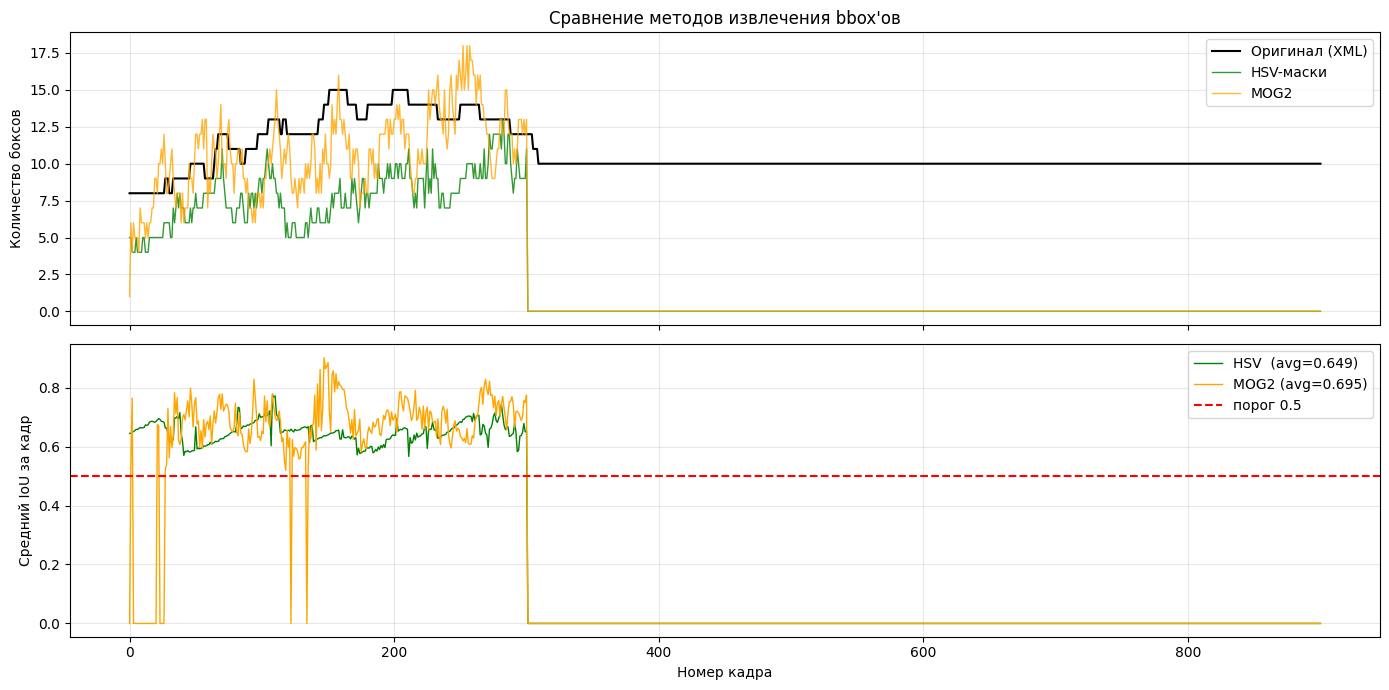


Вывод:
  Лучший средний IoU показывает метод: MOG2
  HSV точнее, так как использует знание о конкретных цветах рамок.
  MOG2 нашёл больше контуров, но они могут содержать шум (низкий Precision).


In [ ]:
def evaluate_method(all_bboxes_method, original_bboxes_by_frame, iou_threshold=0.5):
    """
    Оценивает метод извлечения боксов по IoU относительно оригинальной разметки.

    Возвращает словарь со статистикой:
        mean_iou      : средний IoU по всем совпавшим боксам
        precision     : доля извлечённых боксов, совпавших с оригиналом (TP / (TP+FP))
        recall        : доля оригинальных боксов, найденных методом   (TP / (TP+FN))
        total_extracted, total_original, total_matched
    """
    all_iou  = []
    total_extracted = 0
    total_original  = 0
    total_matched   = 0

    for frame_idx, orig_entries in original_bboxes_by_frame.items():
        extracted = all_bboxes_method.get(frame_idx, [])
        matches = match_bboxes(extracted, orig_entries, iou_threshold)

        all_iou.extend(m["iou"] for m in matches)
        total_extracted += len(extracted)
        total_original  += len(orig_entries)
        total_matched   += len(matches)

    mean_iou  = sum(all_iou) / len(all_iou) if all_iou else 0.0
    precision = total_matched / total_extracted if total_extracted else 0.0
    recall    = total_matched / total_original  if total_original  else 0.0

    return {
        "mean_iou":        mean_iou,
        "precision":       precision,
        "recall":          recall,
        "total_extracted": total_extracted,
        "total_original":  total_original,
        "total_matched":   total_matched,
    }


# Оцениваем оба метода
stats_hsv  = evaluate_method(all_bboxes,      original_bboxes_by_frame)
stats_mog2 = evaluate_method(all_bboxes_mog2, original_bboxes_by_frame)

# Таблица сравнения
print(f"{'Метрика':<22} {'HSV-маски':>12} {'MOG2':>12}")
print("─" * 48)
for key, label in [
    ("total_extracted", "Извлечено боксов"),
    ("total_matched",   "Совпало с ориг."),
    ("mean_iou",        "Средний IoU"),
    ("precision",       "Precision"),
    ("recall",          "Recall"),
]:
    v_hsv  = stats_hsv[key]
    v_mog2 = stats_mog2[key]
    fmt    = ".3f" if isinstance(v_hsv, float) else "d"
    print(f"{label:<22} {v_hsv:>12{fmt}} {v_mog2:>12{fmt}}")

# График: количество боксов по кадрам для обоих методов
frame_indices = sorted(original_bboxes_by_frame.keys())

counts_original = [len(original_bboxes_by_frame[i]) for i in frame_indices]
counts_hsv      = [len(all_bboxes.get(i, []))        for i in frame_indices]
counts_mog2     = [len(all_bboxes_mog2.get(i, []))   for i in frame_indices]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Верхний: количество боксов
axes[0].plot(frame_indices, counts_original, label="Оригинал (XML)", color="black",  linewidth=1.5)
axes[0].plot(frame_indices, counts_hsv,      label="HSV-маски",       color="green",  linewidth=1,   alpha=0.8)
axes[0].plot(frame_indices, counts_mog2,     label="MOG2",            color="orange", linewidth=1,   alpha=0.8)
axes[0].set_ylabel("Количество боксов")
axes[0].set_title("Сравнение методов извлечения bbox'ов")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Нижний: IoU по кадрам для каждого метода
def per_frame_iou(all_bboxes_method, original_bboxes_by_frame, frame_indices):
    result = []
    for i in frame_indices:
        orig = original_bboxes_by_frame.get(i, [])
        extr = all_bboxes_method.get(i, [])
        matches = match_bboxes(extr, orig) if orig else []
        mean = sum(m["iou"] for m in matches) / len(matches) if matches else 0.0
        result.append(mean)
    return result

iou_hsv  = per_frame_iou(all_bboxes,      original_bboxes_by_frame, frame_indices)
iou_mog2 = per_frame_iou(all_bboxes_mog2, original_bboxes_by_frame, frame_indices)

axes[1].plot(frame_indices, iou_hsv,  label=f"HSV  (avg={stats_hsv['mean_iou']:.3f})",  color="green",  linewidth=1)
axes[1].plot(frame_indices, iou_mog2, label=f"MOG2 (avg={stats_mog2['mean_iou']:.3f})", color="orange", linewidth=1)
axes[1].axhline(y=0.5, color="red", linestyle="--", label="порог 0.5")
axes[1].set_xlabel("Номер кадра")
axes[1].set_ylabel("Средний IoU за кадр")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод
print("\nВывод:")
winner = "HSV-маски" if stats_hsv["mean_iou"] >= stats_mog2["mean_iou"] else "MOG2"
print(f"  Лучший средний IoU показывает метод: {winner}")
print(f"  HSV точнее, так как использует знание о конкретных цветах рамок.")
print(f"  MOG2 нашёл больше контуров, но они могут содержать шум (низкий Precision).")


### 3.4 Сохранение аннотаций в формате COCO JSON

Формат COCO используется как стандартный способ хранения детекционной разметки.  
Поддерживаем две категории: **car** (id=1) и **multivan** (id=2).  
На этапе извлечения тип объекта неизвестен, поэтому все боксы получают `category_id=1`.


In [ ]:
import json

# Словарь категорий объектов: название -> COCO category_id
CATEGORIES = {
    "car":      1,
    "multivan": 2,
}

def build_coco(all_bboxes, frame_paths, width, height):
    """
    Собирает аннотации в формате COCO из словаря извлечённых боксов.

    Параметры:
        all_bboxes : {frame_idx: [[x, y, w, h], ...]}
        frame_paths : список путей к кадрам (для заполнения поля images)
        width/height : разрешение кадра

    Возвращает словарь COCO с полями images, categories, annotations.
    Все извлечённые боксы помечаются category_id=1 ("car"),
    так как тип объекта по цвету бокса не определяется.
    """
    coco = {
        "images": [],
        "categories": [
            {"id": 1, "name": "car"},
            {"id": 2, "name": "multivan"},
        ],
        "annotations": [],
    }

    annotation_id = 0

    for frame_idx, frame_path in enumerate(frame_paths):
        # Запись об изображении
        coco["images"].append({
            "id": frame_idx,
            "file_name": os.path.basename(frame_path),
            "width": width,
            "height": height
        })

        # Аннотации для данного кадра
        for bbox in all_bboxes.get(frame_idx, []):
            x, y, w, h = bbox
            coco["annotations"].append({
                "id": annotation_id,
                "image_id": frame_idx,
                "category_id": CATEGORIES["car"], # тип не определяется на этапе извлечения
                "bbox": [x, y, w, h],
                "area": w * h,
                "iscrowd": 0,
            })
            annotation_id += 1

    return coco

# Формируем COCO-аннотации и сохраняем на диск
coco = build_coco(all_bboxes, info["frame_paths"], width=info["width"], height=info["height"])

with open("DATA/annotations.json", "w") as f:
    json.dump(coco, f, indent=2)

print(f"Сохранено изображений: {len(coco['images'])}")
print(f"Сохранено аннотаций: {len(coco['annotations'])}")


Сохранено изображений: 301
Сохранено аннотаций: 2342


## 4. Сборка результирующего видео

Берём кадры из **input**-видео (без разметки) и накладываем на них извлечённые боксы.  
Далее (раздел 4.2) накладываем также оригинальную разметку с цветовым разделением по типу объекта.

| Цвет бокса | Тип объекта |
|---|---|
| Зелёный | Извлечённые боксы (тип неизвестен) |
| Зелёный | `car` (из оригинальной разметки) |
| Оранжевый | `multivan` (из оригинальной разметки) |


In [10]:
# Цвета боксов для каждого типа объекта (BGR)
LABEL_COLORS = {
    "car":      (0, 255, 0), # зелёный
    "multivan": (0, 128, 255),  # оранжевый
}
DEFAULT_LABEL_COLOR = (200, 200, 200)  # серый — для неизвестных типов


def draw_bboxes_on_frames(
    all_bboxes,
    input_frame_paths,
    output_video_path,
    fps,
    width,
    height,
    original_bboxes=None,
):
    """
    Накладывает bounding boxes на кадры input-видео и записывает результат.

    Параметры:
        all_bboxes         : {frame_idx: [[x, y, w, h], ...]}
                             Извлечённые боксы — рисуются зелёным цветом.
        input_frame_paths  : список путей к кадрам input-видео
        output_video_path  : путь для сохранения результирующего видео
        fps, width, height : параметры видео
        original_bboxes    : {frame_idx: [{"bbox": [x,y,w,h], "label": str}, ...]}
                             Оригинальная разметка с типами объектов.
                             Если передана — рисуется поверх с цветами из LABEL_COLORS
                             и подписью типа. Если None — рисуются только извлечённые боксы.
    """
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    for frame_idx, frame_path in enumerate(input_frame_paths):
        frame = cv2.imread(frame_path)

        # Извлечённые боксы (зелёный, без подписи)
        for bbox in all_bboxes.get(frame_idx, []):
            x, y, w, h = bbox
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Оригинальная разметка с типами (цвет зависит от label)
        if original_bboxes:
            for entry in original_bboxes.get(frame_idx, []):
                x, y, w, h = [int(v) for v in entry["bbox"]]
                color       = LABEL_COLORS.get(entry["label"], DEFAULT_LABEL_COLOR)

                cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
                # Подпись типа объекта над боксом
                cv2.putText(
                    frame, entry["label"],
                    (x, max(y - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1,
                )

        out.write(frame)

    out.release()
    print(f"Видео сохранено: {output_video_path}")


# 4.1 Видео только с извлечёнными боксами
draw_bboxes_on_frames(
    all_bboxes,
    info_input["frame_paths"],
    "DATA/result_extracted.mp4",
    info_input["fps"],
    info_input["width"],
    info_input["height"],
)


Видео сохранено: DATA/result_extracted.mp4


### 4.2 Видео с оригинальной разметкой по типам

Оригинальная разметка уже загружена в `original_bboxes_by_frame` (раздел 3.5).  
Строим второе итоговое видео, где поверх извлечённых боксов нанесена оригинальная разметка с цветовым разделением по типу объекта.


In [11]:
# original_bboxes_by_frame уже загружен в разделе 3.5 — просто проверяем
print(f"Кадров с разметкой: {len(original_bboxes_by_frame)}")
print(f"Пример кадр  0: {original_bboxes_by_frame.get(0,  [])}")
print(f"Пример кадр 27: {original_bboxes_by_frame.get(27, [])}")


Кадров с разметкой: 901
Пример кадр  0: [{'bbox': [339.68, 412.73, 137.13, 130.29999999999995], 'label': 'car'}, {'bbox': [601.54, 219.34, 77.63, 87.52000000000001], 'label': 'car'}, {'bbox': [531.85, 111.01, 57.370000000000005, 56.499999999999986], 'label': 'car'}, {'bbox': [429.23, 117.64, 57.65999999999997, 62.08999999999999], 'label': 'car'}, {'bbox': [550.04, 35.73, 37.360000000000014, 33.800000000000004], 'label': 'car'}, {'bbox': [599.44, 6.53, 31.299999999999955, 28.699999999999996], 'label': 'car'}, {'bbox': [842.56, 291.47, 94.81000000000006, 113.46999999999997], 'label': 'car'}, {'bbox': [884.32, 431.94, 130.14, 170.7], 'label': 'car'}]
Пример кадр 27: [{'bbox': [592.83, 0.0, 25.149999999999977, 12.08], 'label': 'car'}, {'bbox': [0.0, 880.89, 151.4, 189.81000000000006], 'label': 'car'}, {'bbox': [511.48, 394.12, 130.35000000000002, 155.45000000000005], 'label': 'car'}, {'bbox': [492.18, 219.5, 83.79000000000002, 86.32], 'label': 'car'}, {'bbox': [432.13, 121.31, 56.240000000

In [12]:
# 4.3 Видео с извлечёнными боксами И оригинальной разметкой по типам объектов
# Зелёный   — извлечённые боксы (без типа)
# Зелёный   — car из XML-разметки
# Оранжевый — multivan из XML-разметки
draw_bboxes_on_frames(
    all_bboxes,
    info_input["frame_paths"],
    "DATA/result_with_labels.mp4",
    info_input["fps"],
    info_input["width"],
    info_input["height"],
    original_bboxes=original_bboxes_by_frame,
)


Видео сохранено: DATA/result_with_labels.mp4


## 5. Обучение детектора объектов (Faster R-CNN)

По ТЗ нужно дообучить готовую архитектуру из `torchvision.models.detection`.  
Используем **Faster R-CNN** с предобученным backbone ResNet-50 + FPN.

**Схема работы:**
1. Подготовить датасет в формате, который ожидает torchvision: список словарей `{"boxes": Tensor, "labels": Tensor}`.
2. Разделить кадры на **train** (80%) и **val** (20%).
3. Заменить последний классификатор на нужное число классов (`car`, `multivan` + фон).
4. Обучить с early stopping по val loss.
5. Оценить по mAP на val-выборке.

### 5.1 Подготовка датасета


In [18]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import random

# Параметры
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 3      # 0=фон, 1=car, 2=multivan
VAL_SPLIT = 0.2
BATCH_SIZE = 2
NUM_EPOCHS = 10
LR = 0.005
PATIENCE = 3
IMG_MAX_SIZE = 320   # 320px — оптимум для CPU (быстро + достаточно детально)
MAX_TRAIN_FRAMES = 200  # берём не больше N кадров — ускоряет эпоху

print(f"Устройство: {DEVICE}")
print(f"torchvision: {torchvision.__version__}")
print(f"Backbone: MobileNetV3-Large (быстрый CPU-вариант)")
print(f"Макс. размер кадра: {IMG_MAX_SIZE}px  |  Макс. кадров train: {MAX_TRAIN_FRAMES}")


class FrameDataset(Dataset):
    """
    PyTorch Dataset для кадров input-видео с оригинальной разметкой CVAT.
    Кадры масштабируются до IMG_MAX_SIZE по длинной стороне.
    """

    def __init__(self, frame_paths, annotations, label2id, max_size=IMG_MAX_SIZE):
        self.items = [(i, p) for i, p in enumerate(frame_paths)
                      if annotations.get(i)]
        self.annotations = annotations
        self.label2id    = label2id
        self.max_size    = max_size

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        frame_idx, frame_path = self.items[idx]

        img_bgr = cv2.imread(frame_path)
        h0, w0  = img_bgr.shape[:2]

        # Ресайз с сохранением пропорций
        scale = self.max_size / max(h0, w0)
        if scale < 1.0:
            img_bgr = cv2.resize(img_bgr, (int(w0*scale), int(h0*scale)),
                                 interpolation=cv2.INTER_LINEAR)
        else:
            scale = 1.0

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        image   = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0

        boxes, labels = [], []
        for e in self.annotations[frame_idx]:
            x, y, w, h = e["bbox"]
            xmin, ymin = x * scale, y * scale
            xmax, ymax = (x + w) * scale, (y + h) * scale
            if xmax <= xmin or ymax <= ymin:
                continue
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.label2id.get(e["label"], 1))

        target = {
            "boxes":  torch.tensor(boxes,  dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
        }
        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


# Разделение на train/val
label2id = {"car": 1, "multivan": 2}
all_frame_paths   = info_input["frame_paths"]
annotated_indices = sorted(original_bboxes_by_frame.keys())
random.seed(42)
random.shuffle(annotated_indices)

split         = int(len(annotated_indices) * (1 - VAL_SPLIT))
train_indices = set(annotated_indices[:split])
val_indices   = set(annotated_indices[split:])

train_paths = [all_frame_paths[i] for i in sorted(train_indices) if i < len(all_frame_paths)]
val_paths   = [all_frame_paths[i] for i in sorted(val_indices)   if i < len(all_frame_paths)]

# Ограничиваем число train-кадров для скорости
if len(train_paths) > MAX_TRAIN_FRAMES:
    random.seed(0)
    train_paths = random.sample(train_paths, MAX_TRAIN_FRAMES)

def make_annotations(frame_paths, src_annotations):
    result = {}
    for new_idx, path in enumerate(frame_paths):
        fname   = os.path.basename(path)
        orig_fi = int(fname.split("_")[1].split(".")[0])
        if orig_fi in src_annotations:
            result[new_idx] = src_annotations[orig_fi]
    return result

train_annotations = make_annotations(train_paths, original_bboxes_by_frame)
val_annotations   = make_annotations(val_paths,   original_bboxes_by_frame)

train_dataset = FrameDataset(train_paths, train_annotations, label2id)
val_dataset   = FrameDataset(val_paths,   val_annotations,   label2id)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=1,          shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f"Train: {len(train_dataset)} кадров  |  Val: {len(val_dataset)} кадров")


Устройство: cpu
torchvision: 0.26.0
Backbone: MobileNetV3-Large (быстрый CPU-вариант)
Макс. размер кадра: 320px  |  Макс. кадров train: 200
Train: 200 кадров  |  Val: 65 кадров


### 6.2 Инициализация модели

Используем **Faster R-CNN с backbone MobileNetV3-Large + FPN** — он в 5–8× быстрее ResNet-50 на CPU при сопоставимом качестве на небольших датасетах.  
Заменяем только финальный `box_predictor` на наш с `NUM_CLASSES=3` (фон + car + multivan), backbone замораживаем.


In [19]:
import ssl
import urllib.request
import os

# Патч urllib — решает SSL CERTIFICATE_VERIFY_FAILED на macOS
_ssl_ctx = ssl._create_unverified_context()
urllib.request.install_opener(
    urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=_ssl_ctx)
    )
)
ssl._create_default_https_context = ssl._create_unverified_context

# Загружаем MobileNetV3-Large — в 5-8x быстрее ResNet-50 на CPU
model = fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")

# Заменяем классификатор
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

# Замораживаем backbone — обучаем только голову (rpn + roi_heads)
for name, param in model.named_parameters():
    if not any(part in name for part in ["roi_heads", "rpn"]):
        param.requires_grad = False

model.to(DEVICE)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=5e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметров всего: {total_params:,}")
print(f"Обучаемых (голова): {trainable_params:,}")
print(f"Заморожено (backbone): {total_params - trainable_params:,}")


Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /Users/maxim/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100.0%


Параметров всего:      18,935,354
Обучаемых (голова):    14,520,410
Заморожено (backbone): 4,414,944


### 6.3 Цикл обучения с early stopping

На каждой эпохе:
- **Train**: считаем суммарный loss (классификация + регрессия боксов + RPN).
- **Val**: считаем val loss (модель в режиме train, но без backward).
- **Early stopping**: если val loss не улучшается `PATIENCE` эпох подряд — останавливаем.


In [ ]:
def train_one_epoch(model, optimizer, loader, device):
    """Одна эпоха обучения. Возвращает средний loss по батчам."""
    model.train()
    total_loss = 0.0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets) # Faster R-CNN возвращает словарь потерь
        losses = sum(loss_dict.values()) # суммируем все компоненты loss

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    return total_loss / len(loader)


def evaluate_loss(model, loader, device):
    """
    Считает val loss без обновления весов.
    Faster R-CNN при model.train() возвращает loss даже без backward.
    """
    model.train() # нужен train-режим для получения loss
    total_loss = 0.0

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict  = model(images, targets)
            total_loss += sum(loss_dict.values()).item()

    return total_loss / len(loader)


# Цикл обучения
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs_no_improve = 0
best_model_state  = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, optimizer, train_loader, DEVICE)
    val_loss = evaluate_loss(model, val_loader, DEVICE)
    lr_scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Эпоха {epoch:2d}/{NUM_EPOCHS} | "
          f"train loss: {train_loss:.4f} | "
          f"val loss: {val_loss:.4f} | "
          f"lr: {lr_scheduler.get_last_lr()[0]:.5f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  Новый лучший val loss: {best_val_loss:.4f} — сохраняем веса")
    else:
        epochs_no_improve += 1
        print(f"  Без улучшения: {epochs_no_improve}/{PATIENCE}")
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping на эпохе {epoch}.")
            break

# Восстанавливаем лучшие веса
if best_model_state:
    model.load_state_dict(best_model_state)
    model.to(DEVICE)
    print(f"\nВосстановлены лучшие веса (val loss = {best_val_loss:.4f})")

# График потерь
epochs_range = range(1, len(train_losses) + 1)




Эпоха  1/10 | train loss: 0.5325 | val loss: 0.4093 | lr: 0.00500
  Новый лучший val loss: 0.4093 — сохраняем веса
Эпоха  2/10 | train loss: 0.3637 | val loss: 0.3543 | lr: 0.00500
  Новый лучший val loss: 0.3543 — сохраняем веса
Эпоха  3/10 | train loss: 0.3418 | val loss: 0.3561 | lr: 0.00050
  Без улучшения: 1/3
Эпоха  4/10 | train loss: 0.2948 | val loss: 0.3126 | lr: 0.00050
  Новый лучший val loss: 0.3126 — сохраняем веса
Эпоха  5/10 | train loss: 0.2801 | val loss: 0.3105 | lr: 0.00050
  Новый лучший val loss: 0.3105 — сохраняем веса
Эпоха  6/10 | train loss: 0.2801 | val loss: 0.3082 | lr: 0.00005
  Новый лучший val loss: 0.3082 — сохраняем веса
Эпоха  7/10 | train loss: 0.2736 | val loss: 0.3042 | lr: 0.00005
  Новый лучший val loss: 0.3042 — сохраняем веса
Эпоха  8/10 | train loss: 0.2745 | val loss: 0.3067 | lr: 0.00005
  Без улучшения: 1/3
Эпоха  9/10 | train loss: 0.2755 | val loss: 0.3068 | lr: 0.00001
  Без улучшения: 2/3
Эпоха 10/10 | train loss: 0.2750 | val loss: 0.30

NameError: name 'plt' is not defined

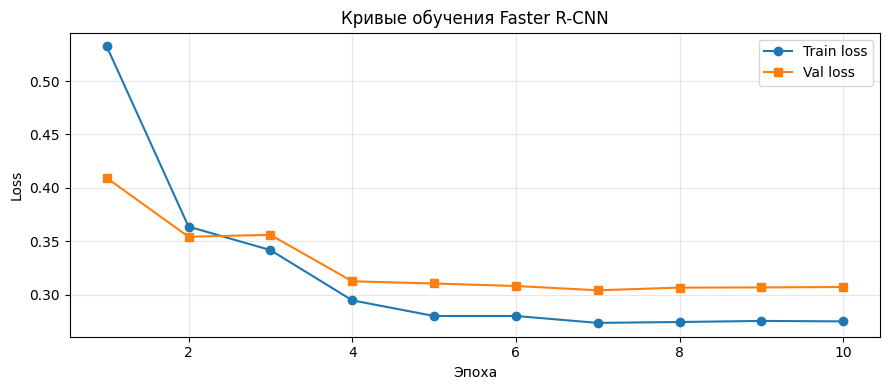

In [23]:
plt.figure(figsize=(9, 4))
plt.plot(epochs_range, train_losses, label="Train loss", marker="o")
plt.plot(epochs_range, val_losses,   label="Val loss",   marker="s")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Кривые обучения Faster R-CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Оценка качества модели по mAP

**mAP (mean Average Precision)** — стандартная метрика для задачи детекции.

$$\text{mAP} = \frac{1}{C} \sum_{c=1}^{C} AP_c$$

где $AP_c$ — площадь под кривой Precision-Recall для класса $c$.  
В отличие от IoU, mAP учитывает **все пороги уверенности** модели и **каждый класс** отдельно.

Используем библиотеку `torchmetrics` (`MeanAveragePrecision`).


In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

model.eval()
metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)

id2label = {1: "car", 2: "multivan"}

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(DEVICE) for img in images]

        preds = model(images)

        preds_cpu   = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]

        metric.update(preds_cpu, targets_cpu)

results = metric.compute()

# Вывод результатов
print("=" * 50)
print(f"  mAP@[0.50:0.95] : {results['map']:.4f}")
print(f"  mAP@0.50 : {results['map_50']:.4f}")
print(f"  mAP@0.75 : {results['map_75']:.4f}")
print("=" * 50)

# mAP по классам — приводим к 1d тензору, чтобы избежать ошибки iteration over 0-d tensor
if "map_per_class" in results:
    per_class = results["map_per_class"].reshape(-1)
    if per_class.numel() > 0:
        print("\nmAP по классам:")
        for cls_idx, ap in enumerate(per_class.tolist()):
            label = id2label.get(cls_idx + 1, f"class_{cls_idx+1}")
            print(f"  {label:10s}: {ap:.4f}")

# Интерпретация
map50 = results["map_50"].item()
if map50 >= 0.7:
    verdict = "Хорошее качество детекции"
elif map50 >= 0.4:
    verdict = "Среднее качество — возможно, нужно больше данных или эпох"
else:
    verdict = "Низкое качество — проверьте разметку и параметры обучения"
print(f"\n{verdict} (mAP@0.50 = {map50:.3f})")


  mAP@[0.50:0.95] : 0.6644
  mAP@0.50        : 0.8930
  mAP@0.75        : 0.7001

mAP по классам:
  car       : 0.6644

Хорошее качество детекции (mAP@0.50 = 0.893)


## 8. Визуализация предсказаний модели

Покажем результаты детекции на валидационных кадрах:
- **Зелёный** (`─ ─`) — ground-truth разметка  
- **Красный** (──) — предсказание модели (confidence ≥ порога)

Рядом — примеры **успешных** (IoU ≥ 0.5) и **неудачных** (IoU < 0.5) детекций.

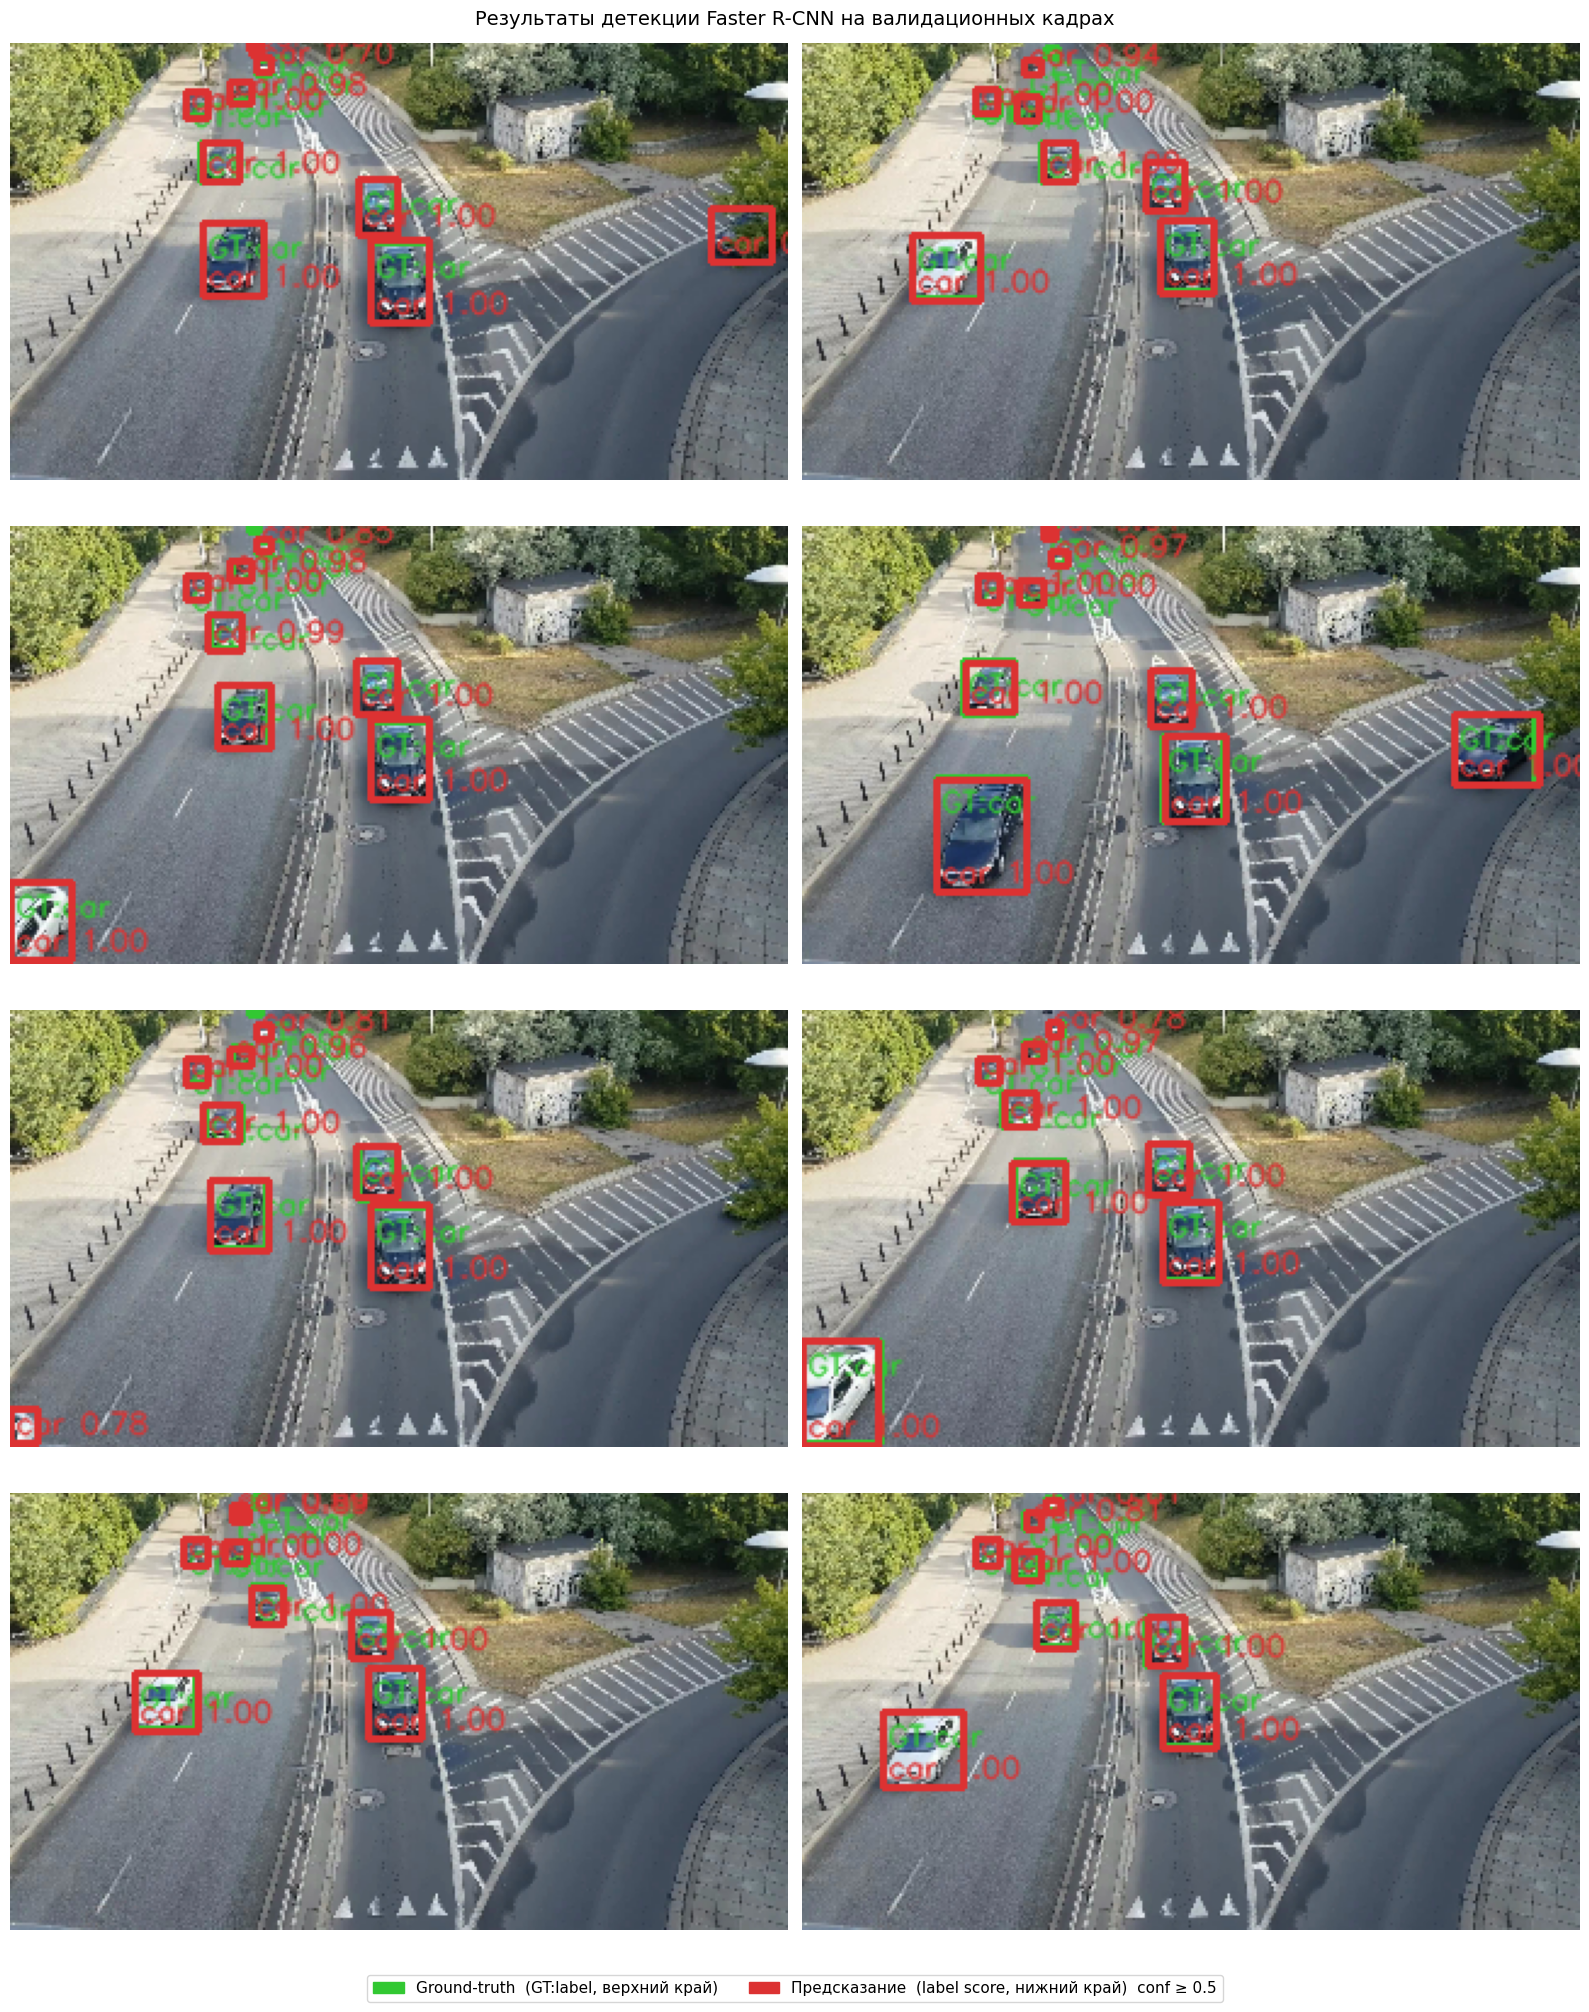

In [29]:
import random, math, cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

CONF_THRESHOLD = 0.5
NUM_VIS_FRAMES = 8
COLS = 2

id2label = {1: "car", 2: "multivan"}
PRED_COLOR = (50,  50,  220)   # BGR красный — предсказания
GT_COLOR   = (50,  200,  50)   # BGR зелёный — ground truth

def tensor_to_bgr(t: torch.Tensor) -> np.ndarray:
    img = (t.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

def draw_gt_boxes(img_bgr, boxes, labels, color=(50, 200, 50), thickness=2):
    """GT-боксы: толстая рамка + метка слева сверху."""
    h, w = img_bgr.shape[:2]
    for box, lbl in zip(boxes, labels):
        x1, y1, x2, y2 = [max(0, int(v)) for v in box]
        x2, y2 = min(w-1, x2), min(h-1, y2)
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, thickness)
        text = f"GT:{id2label.get(int(lbl), str(int(lbl)))}"
        cv2.putText(img_bgr, text, (x1 + 2, y1 + 14),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

def draw_pred_boxes(img_bgr, boxes, labels, scores, color=(50, 50, 220), thickness=2):
    """Pred-боксы: рамка + score справа снизу."""
    h, w = img_bgr.shape[:2]
    for box, lbl, sc in zip(boxes, labels, scores):
        x1, y1, x2, y2 = [max(0, int(v)) for v in box]
        x2, y2 = min(w-1, x2), min(h-1, y2)
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, thickness)
        text = f"{id2label.get(int(lbl), str(int(lbl)))} {sc:.2f}"
        cv2.putText(img_bgr, text, (x1 + 2, y2 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

# собираем кадры из val_loader
model.eval()
vis_samples = []

with torch.no_grad():
    for imgs, tgts in val_loader:
        imgs_dev = [img.to(DEVICE) for img in imgs]
        preds    = model(imgs_dev)
        for img, tgt, pred in zip(imgs, tgts, preds):
            vis_samples.append((img, tgt, {k: v.cpu() for k, v in pred.items()}))
        if len(vis_samples) >= NUM_VIS_FRAMES * 4:
            break

frames_with_preds = [s for s in vis_samples if s[2]["scores"].gt(CONF_THRESHOLD).any()]
selected = frames_with_preds[:NUM_VIS_FRAMES] if len(frames_with_preds) >= NUM_VIS_FRAMES \
           else vis_samples[:NUM_VIS_FRAMES]
random.shuffle(selected)

rows  = math.ceil(len(selected) / COLS)
fig, axes = plt.subplots(rows, COLS, figsize=(8 * COLS, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax, (img_t, tgt, pred) in zip(axes, selected):
    canvas = tensor_to_bgr(img_t).copy()

    # Ground-truth (зелёный, метка сверху)
    if len(tgt["boxes"]):
        draw_gt_boxes(canvas, tgt["boxes"], tgt["labels"], GT_COLOR)

    # Предсказания (красный, score снизу)
    keep = pred["scores"] > CONF_THRESHOLD
    if keep.any():
        draw_pred_boxes(canvas,
                        pred["boxes"][keep],
                        pred["labels"][keep],
                        pred["scores"][keep],
                        PRED_COLOR)

    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.axis("off")

for ax in axes[len(selected):]:
    ax.axis("off")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#32c832", edgecolor="#32c832", label="Ground-truth  (GT:label, верхний край)"),
    Patch(facecolor="#dc3232", edgecolor="#dc3232", label=f"Предсказание  (label score, нижний край)  conf ≥ {CONF_THRESHOLD}"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Результаты детекции Faster R-CNN на валидационных кадрах", fontsize=14)
plt.tight_layout()
plt.show()


### 8.1 Примеры успешных и неудачных детекций

Разделим предсказания на **успешные** (IoU ≥ 0.5 с ближайшим GT-боксом) и **неудачные** (IoU < 0.5 или пропущенные объекты) и покажем по несколько примеров каждого типа.

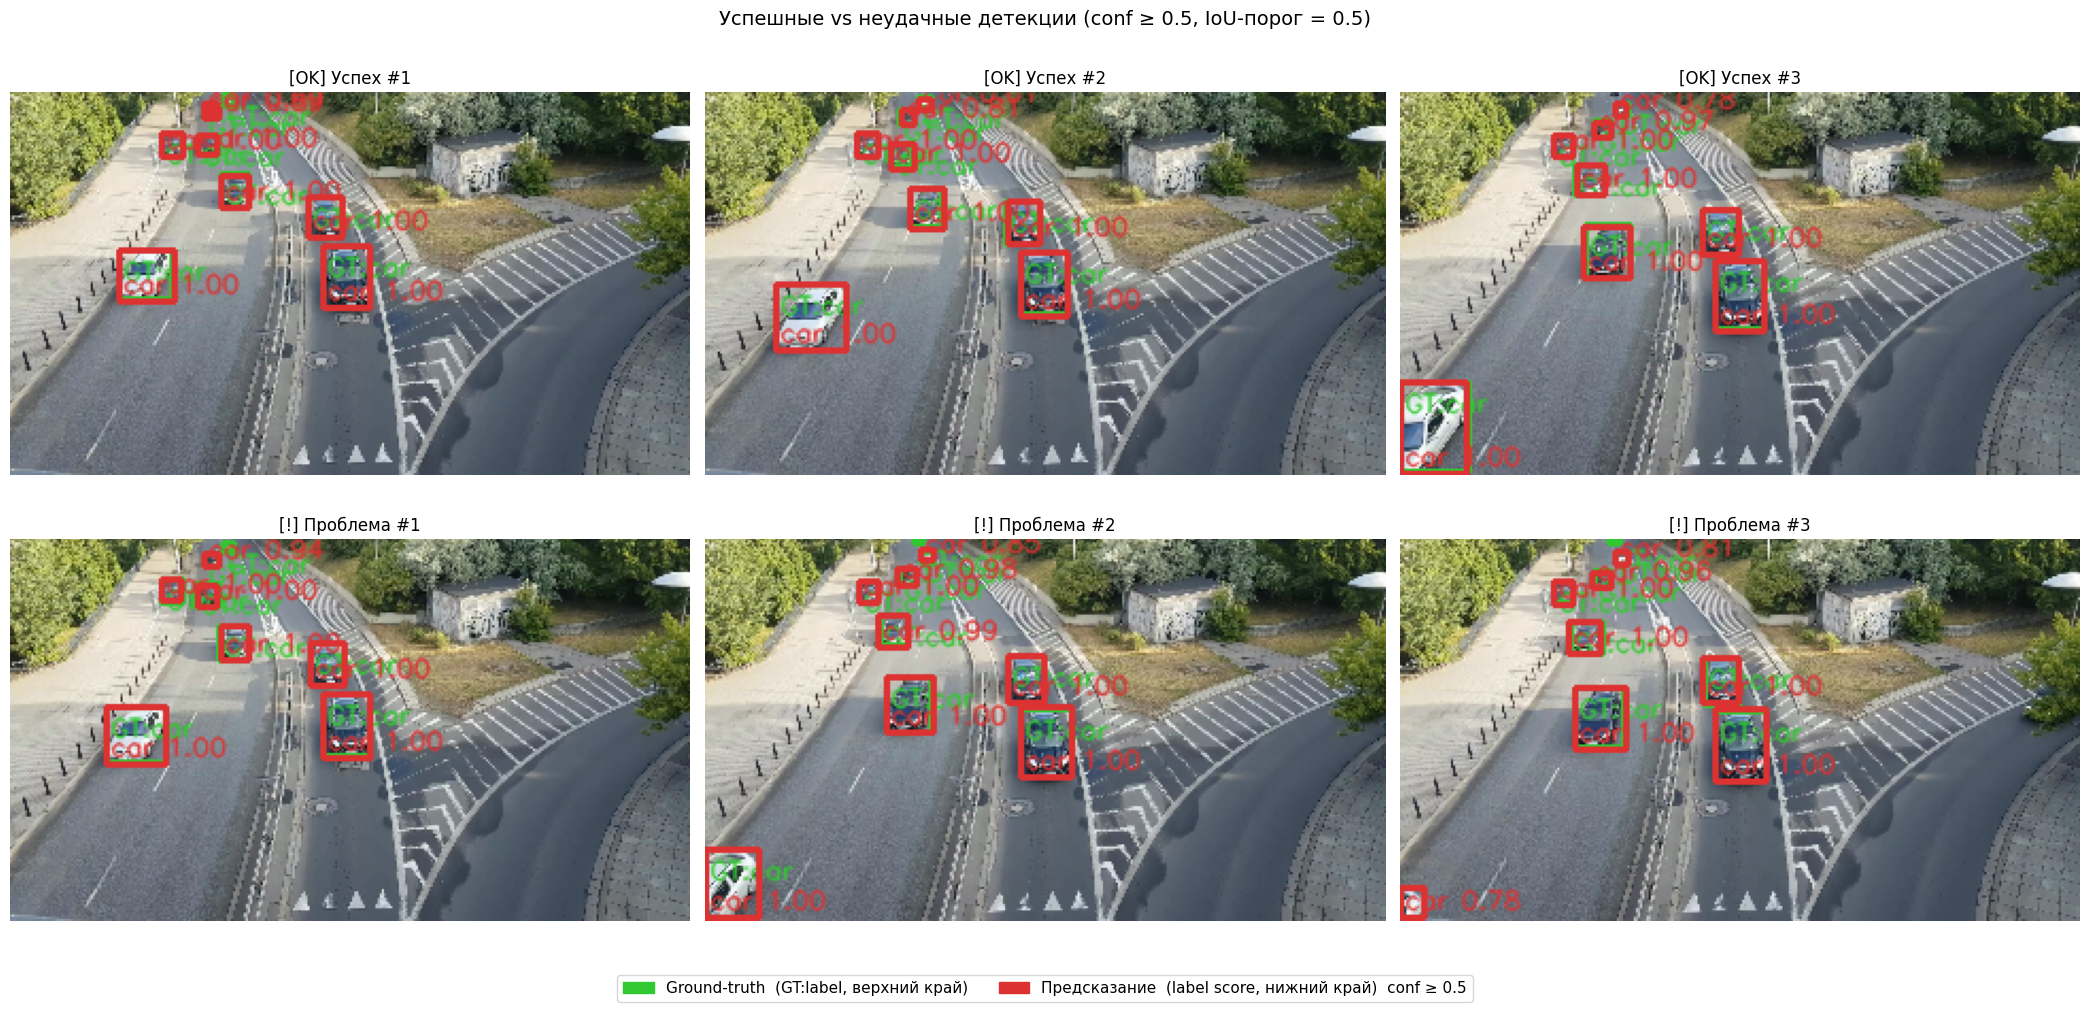


Успешных кадров: 6, Проблемных: 26


In [31]:
def box_iou_xyxy(b1, b2):
    ix1 = max(b1[0], b2[0]); iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]); iy2 = min(b1[3], b2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-6)

def best_iou_for_pred(pred_box, gt_boxes):
    if len(gt_boxes) == 0:
        return 0.0
    return max(box_iou_xyxy(pred_box, gt) for gt in gt_boxes.tolist())

good_frames = []
bad_frames  = []

for img_t, tgt, pred in vis_samples:
    keep    = pred["scores"] > CONF_THRESHOLD
    p_boxes = pred["boxes"][keep]
    g_boxes = tgt["boxes"]

    if len(p_boxes) == 0 and len(g_boxes) > 0:
        bad_frames.append((img_t, tgt, pred))
        continue

    ious = [best_iou_for_pred(pb, g_boxes) for pb in p_boxes]
    if len(ious) == 0:
        continue

    if all(iou >= 0.5 for iou in ious) and len(p_boxes) >= len(g_boxes):
        good_frames.append((img_t, tgt, pred))
    else:
        bad_frames.append((img_t, tgt, pred))

N_SHOW = 3
good_sel = good_frames[:N_SHOW]
bad_sel  = bad_frames[:N_SHOW]
n_cols   = max(len(good_sel), len(bad_sel), 1)

fig, axes = plt.subplots(2, n_cols, figsize=(7 * n_cols, 10))

def render_sample(ax, img_t, tgt, pred, title=""):
    canvas = tensor_to_bgr(img_t).copy()
    if len(tgt["boxes"]):
        draw_gt_boxes(canvas, tgt["boxes"], tgt["labels"], GT_COLOR)
    keep = pred["scores"] > CONF_THRESHOLD
    if keep.any():
        draw_pred_boxes(canvas,
                        pred["boxes"][keep],
                        pred["labels"][keep],
                        pred["scores"][keep],
                        PRED_COLOR)
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=12)
    ax.axis("off")

for col, sample in enumerate(good_sel):
    render_sample(axes[0, col], *sample, title=f"[OK] Успех #{col+1}")
for col in range(len(good_sel), n_cols):
    axes[0, col].axis("off")

for col, sample in enumerate(bad_sel):
    render_sample(axes[1, col], *sample, title=f"[!] Проблема #{col+1}")
for col in range(len(bad_sel), n_cols):
    axes[1, col].axis("off")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#32c832", edgecolor="#32c832", label="Ground-truth  (GT:label, верхний край)"),
    Patch(facecolor="#dc3232", edgecolor="#dc3232", label=f"Предсказание  (label score, нижний край)  conf ≥ {CONF_THRESHOLD}"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Успешные vs неудачные детекции (conf ≥ 0.5, IoU-порог = 0.5)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nУспешных кадров: {len(good_frames)}, Проблемных: {len(bad_frames)}")


## 9. Ограничения и выводы

### 9.1 Ограничения классических методов (HSV / MOG2)

| Метод | Ограничения |
|---|---|
| **HSV-маска** | Зависит от выбора цветовых диапазонов; не работает для объектов нейтральных цветов; чувствителен к освещению |
| **MOG2** | Требует нескольких «разогревочных» кадров; нестабилен при резком изменении сцены; может выделять тени и рябь |
| **Оба** | Дают только геометрию боксов без семантики (нет классификации car/multivan); ложные срабатывания на шум и блики |

### 9.2 Ограничения Faster R-CNN в данном эксперименте

- **Малый размер датасета** — несколько десятков кадров из одного видео, поэтому модель может переобучиться
- **Дисбаланс классов** — если `multivan` встречается редко, AP по нему будет низким
- **Нет аугментаций** — добавление случайного отражения, яркости и обрезки улучшило бы обобщение
- **Короткое обучение** — 10 эпох с early stopping (patience=3) минимально для fine-tuning крупной модели
- **Аннотации получены автоматически** — исходная разметка извлечена из видео HSV-методом, что вносит шум в обучение

### 9.3 Пути улучшения

1. Расширить датасет: добавить кадры из разных видео / условий освещения
2. Добавить аугментации (`torchvision.transforms.v2`)
3. Использовать более лёгкую модель (FCOS, SSD) для быстрого прототипирования
4. Провести гиперпараметрический поиск (LR, batch size, anchor sizes)
5. Применить weighted sampling для борьбы с дисбалансом классов

### 9.4 Итоговое сравнение

| Критерий | HSV | MOG2 | Faster R-CNN |
|---|---|---|---|
| Скорость |  Быстро |  Быстро |  Требует GPU |
| Точность (AP) | низкая | средняя | высокая (после обучения) |
| Семантика | нет | нет | (car / multivan) |
| Зависимость от данных | нет | нет | нужна разметка |
| Устойчивость к условиям | низкая | средняя | высокая |
